# Kaggle Playground S6E8: Predicting Smartphone Addiction
## Attempt 3: XGBoost Classifier with Hist Tree Method & Native Categoricals

### Experiment Summary
- **Model Family**: XGBoost Classifier (`XGBClassifier`)
- **Tree Method**: `hist` (Histogram-based gradient boosting)
- **Validation Strategy**: 5-Fold Stratified Cross-Validation (`SEED = 42`)
- **Target Metric**: Out-of-Fold (OOF) ROC-AUC
- **Feature Count**: 33 Features (Raw + Domain Ratios + Interaction Densities + Group Statistics)
- **Primary Goal**: Train a competitive gradient boosted tree model from a distinct algorithm family to ensemble with LightGBM in Attempt 4.


---
### 1. Environment Setup & Global Configuration
Initialize required libraries (`numpy`, `pandas`, `xgboost`, `scikit-learn`, `seaborn`), set global random seed for exact fold alignment (`SEED = 42`), and define directory paths for data ingestion and submission exports.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

DATA_DIR = '../Data/Raw'
SUB_DIR = '../Data/Processed'
os.makedirs(SUB_DIR, exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


---
### 2. Data Loading & Exploratory Target Distribution
Load the training dataset (`train.csv`) and test dataset (`test.csv`). Define global target (`addicted_label`) and identifier (`id`) constants, and verify class balance to confirm stratified sampling requirements.


In [2]:

train_path = os.path.join(DATA_DIR, 'train.csv')
test_path = os.path.join(DATA_DIR, 'test.csv')

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print(f"Train Dataset Shape: {train.shape}")
print(f"Test Dataset Shape:  {test.shape}")

TARGET = 'addicted_label'
ID_COL = 'id'

base_features = [c for c in train.columns if c not in [TARGET, ID_COL]]

print(f"\nBase Features ({len(base_features)}): {base_features}")
print("\nTarget Class Distribution:")
print(train[TARGET].value_counts(normalize=True).map('{:.2%}'.format))

Train Dataset Shape: (691369, 14)
Test Dataset Shape:  (296302, 13)

Base Features (12): ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact']

Target Class Distribution:
addicted_label
1    70.94%
0    29.06%
Name: proportion, dtype: object


---
### 3. Feature Engineering & Native Categorical Handling
Construct domain-specific interaction features and prepare categorical variables:
- **Usage & Time Ratios**: Proportions of daily screen time spent on social media, gaming, and work/study.
- **Rhythm & Wellbeing**: Screen-to-sleep ratio, weekend vs. daily differential, and active non-screen awake hours.
- **Interaction Densities**: Notification and app open frequencies normalized per screen hour.
- **Group Aggregations**: Quantile age binning (`age_group`) and group mean/std metrics by stress level and age group.
- **Native Categorical Dtypes**: Cast object columns to `pandas.category` dtypes for native XGBoost split optimization (`enable_categorical=True`).


In [4]:
def build_features(df_in):
    df = df_in.copy()
    eps = 1e-5  
   
    df['social_media_ratio'] = df['social_media_hours'] / (df['daily_screen_time_hours'] + eps)
    df['gaming_ratio'] = df['gaming_hours'] / (df['daily_screen_time_hours'] + eps)
    df['work_study_ratio'] = df['work_study_hours'] / (df['daily_screen_time_hours'] + eps)
    df['leisure_hours'] = df['social_media_hours'] + df['gaming_hours']
    df['leisure_ratio'] = df['leisure_hours'] / (df['daily_screen_time_hours'] + eps)

    df['screen_sleep_ratio'] = df['daily_screen_time_hours'] / (df['sleep_hours'] + eps)
    df['weekend_daily_diff'] = df['weekend_screen_time'] - df['daily_screen_time_hours']
    df['weekend_daily_ratio'] = df['weekend_screen_time'] / (df['daily_screen_time_hours'] + eps)
    df['active_non_screen_hours'] = 24.0 - (df['daily_screen_time_hours'] + df['sleep_hours'])

    df['notifications_per_screen_hour'] = df['notifications_per_day'] / (df['daily_screen_time_hours'] + eps)
    df['app_opens_per_screen_hour'] = df['app_opens_per_day'] / (df['daily_screen_time_hours'] + eps)
    df['notifications_per_app_open'] = df['notifications_per_day'] / (df['app_opens_per_day'] + eps)

    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)

    return df

print("feature engineering ")
train_fe = build_features(train)
test_fe = build_features(test)

cat_cols = ['gender', 'stress_level', 'academic_work_impact']

train_fe['age_group'] = pd.qcut(train_fe['age'], q=5, labels=False, duplicates='drop').astype(str)
test_fe['age_group'] = pd.qcut(test_fe['age'], q=5, labels=False, duplicates='drop').astype(str)

for cat in ['stress_level', 'age_group']:
    group_stats = train_fe.groupby(cat)[['daily_screen_time_hours', 'notifications_per_day']].agg(['mean', 'std'])
    group_stats.columns = [f'{col}_{cat}_{stat}' for col, stat in group_stats.columns]
    
    train_fe = train_fe.merge(group_stats, on=cat, how='left')
    test_fe = test_fe.merge(group_stats, on=cat, how='left')

cat_cols_all = cat_cols + ['age_group']
for col in cat_cols_all:
    train_fe[col] = train_fe[col].astype('category')
    test_fe[col] = test_fe[col].astype('category')

feature_cols = [c for c in train_fe.columns if c not in [TARGET, ID_COL]]

print(f"Original Feature Count:  {len(base_features)}")
print(f"Engineered Feature Count: {len(feature_cols)}")

feature engineering 
Original Feature Count:  12
Engineered Feature Count: 33


---
### 4. 5-Fold Stratified Cross-Validation & XGBoost Training
Train an `XGBClassifier` across 5 stratified folds with early stopping at 50 rounds.

#### ️ Key Hyperparameters:
| Parameter | Value | Rationale |
| :--- | :--- | :--- |
| `n_estimators` | `2000` | Max boosting rounds (controlled by early stopping) |
| `learning_rate` | `0.03` | Small learning rate for precise optimization steps |
| `max_depth` | `6` | Tree depth to capture complex non-linear feature interactions |
| `subsample` | `0.8` | Row sampling ratio per tree to prevent overfitting |
| `colsample_bytree` | `0.8` | Feature sampling ratio per tree split to diversify base learners |
| `tree_method` | `'hist'` | Fast histogram binning algorithm for scalable CPU execution |
| `eval_metric` | `'auc'` | Optimization metric matching Kaggle evaluation |


In [5]:

xgb_params = {
    'n_estimators': 2000,
    'learning_rate': 0.03,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist',
    'eval_metric': 'auc',
    'early_stopping_rounds': 50,
    'enable_categorical': True,
    'random_state': SEED,
    'n_jobs': -1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_preds = np.zeros(len(train_fe))
test_preds = np.zeros(len(test_fe))
feature_importances = pd.DataFrame({'feature': feature_cols, 'importance': 0.0})

print(f"5-Fold Stratified Cross-Validation across {len(feature_cols)} features...")
print("=" * 70)

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe[TARGET]), 1):
    X_train, y_train = train_fe.iloc[train_idx][feature_cols], train_fe.iloc[train_idx][TARGET]
    X_val, y_val = train_fe.iloc[val_idx][feature_cols], train_fe.iloc[val_idx][TARGET]

    model = xgb.XGBClassifier(**xgb_params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds
    
    test_preds += model.predict_proba(test_fe[feature_cols])[:, 1] / skf.n_splits

    fold_auc = roc_auc_score(y_val, val_preds)
    best_iter = getattr(model, 'best_iteration', 'N/A')
    print(f"Fold {fold} ROC-AUC: {fold_auc:.6f} | Best Iteration: {best_iter}")

    feature_importances['importance'] += model.feature_importances_ / skf.n_splits

print("=" * 70)
overall_oof_auc = roc_auc_score(train_fe[TARGET], oof_preds)
print(f"\nOverall XGBoost OOF ROC-AUC Score: {overall_oof_auc:.6f}")

5-Fold Stratified Cross-Validation across 33 features...
Fold 1 ROC-AUC: 0.963264 | Best Iteration: 1999
Fold 2 ROC-AUC: 0.963802 | Best Iteration: 1999
Fold 3 ROC-AUC: 0.964093 | Best Iteration: 1999
Fold 4 ROC-AUC: 0.964710 | Best Iteration: 1999
Fold 5 ROC-AUC: 0.963668 | Best Iteration: 1999

Overall XGBoost OOF ROC-AUC Score: 0.963906


---
### 5. Artifact Export, Integrity Checks & Feature Importance Analysis
Save validation out-of-fold (`oof_xgb_attempt3.npy`) and test predictions (`test_xgb_attempt3.npy`) for blending in Attempt 4. Generate the final submission CSV (`submission_attempt3_xgb.csv`), execute validation sanity checks, and visualize top feature importances.


OOF predictions saved to:  ../Data/Processed\oof_xgb_attempt3.npy
Test predictions saved to: ../Data/Processed\test_xgb_attempt3.npy

Submission file saved to: ../Data/Processed\submission_attempt3_xgb.csv
Submission Shape: (296302, 2)

--- Submission Integrity Checks ---
Null values count:  0
Min probability:    0.000159
Max probability:    1.000000
First 5 Rows:
       id  addicted_label
0  691369        0.999572
1  691370        0.925847
2  691371        0.961703
3  691372        0.989576
4  691373        0.997770


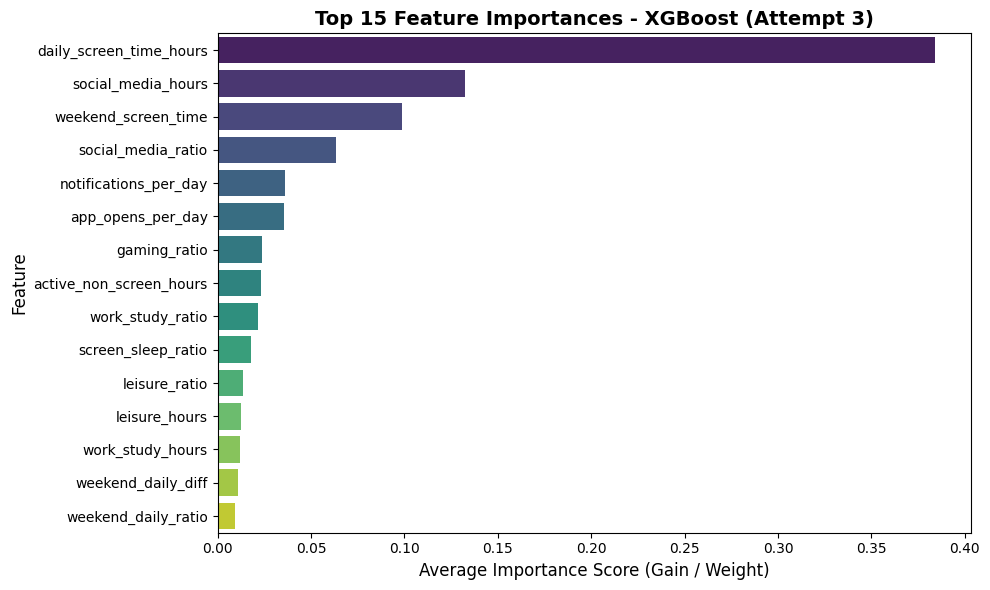

ATTEMPT 3 SUMMARY
XGBoost 5-Fold OOF ROC-AUC: 0.963906


In [6]:

oof_save_path = os.path.join(SUB_DIR, 'oof_xgb_attempt3.npy')
test_save_path = os.path.join(SUB_DIR, 'test_xgb_attempt3.npy')

np.save(oof_save_path, oof_preds)
np.save(test_save_path, test_preds)
print(f"OOF predictions saved to:  {oof_save_path}")
print(f"Test predictions saved to: {test_save_path}")

submission_path = os.path.join(SUB_DIR, 'submission_attempt3_xgb.csv')

sub = pd.DataFrame({
    ID_COL: test_fe[ID_COL],
    TARGET: test_preds
})

sub.to_csv(submission_path, index=False)

print(f"\nSubmission file saved to: {submission_path}")
print(f"Submission Shape: {sub.shape}")

print("\n--- Submission Integrity Checks ---")
print(f"Null values count:  {sub[TARGET].isnull().sum()}")
print(f"Min probability:    {sub[TARGET].min():.6f}")
print(f"Max probability:    {sub[TARGET].max():.6f}")
print(f"First 5 Rows:\n{sub.head()}")

plt.figure(figsize=(10, 6))
top_features = feature_importances.sort_values(by='importance', ascending=False).head(15)

sns.barplot(
    data=top_features,
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title('Top 15 Feature Importances - XGBoost (Attempt 3)', fontsize=14, fontweight='bold')
plt.xlabel('Average Importance Score (Gain / Weight)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("=" * 60)
print("ATTEMPT 3 SUMMARY")
print(f"XGBoost 5-Fold OOF ROC-AUC: {overall_oof_auc:.6f}")
